# Library download

In [ ]:
import json    
import math
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Data download and preparaition

In [ ]:
desc_path = "ENTER_YOUR_MALE_FEMALE_CSV"
param_path = "ENTER_YOUR_RESULTS_CSV"
json_path = "ENTER_YOUR_JSON_DICT"


desc = pd.read_csv(desc_path)
params = pd.read_csv(param_path)

with open(json_path, "r") as f:
    mapping = json.load(f)


params["call_id"] = params["call_id"].map(mapping)
desc["audio_id"] = desc["audio_id"].str[:-4]

In [11]:
desc = desc.rename(columns={"audio_id": "call_id"})
merged = params.merge(desc, on="call_id", how="left")
merged["sex"] = merged.apply(
    lambda row: row["target_sex"] if row["role"] == "target" else row["operator_sex"],
    axis=1
)
merged["sex"] = merged["sex"].replace("-", None)
merged.drop(columns=["operator_sex", "target_sex"], inplace=True)
merged["call_id"] = merged["call_id"].astype(str)

In [32]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   call_id      180 non-null    object 
 1   role         180 non-null    object 
 2   f0_mean      180 non-null    float64
 3   f0_variance  180 non-null    float64
 4   f1_mean      180 non-null    float64
 5   f1_variance  180 non-null    float64
 6   f2_mean      180 non-null    float64
 7   f2_variance  180 non-null    float64
 8   f3_mean      180 non-null    float64
 9   f3_variance  180 non-null    float64
 10  sex          166 non-null    object 
dtypes: float64(8), object(3)
memory usage: 15.6+ KB


---

## Prepairing for PCA analysis

Данный блок будет построен со следующими критериями:
- Отношение оператор/пользователь во всех данных
- Отношение мужчин/женщин в категории пользователь
- Отношение мужчин/женщин в категории оператор
- Отношение оператор/пользователь в категории мужчины
- Отношение оператор/пользователь в категории женщины


In [13]:
print("Используемые признаки:")
for num, column in enumerate(merged.select_dtypes(include=[np.number]).columns):
    print(f'{num+1}) {column}')

Используемые признаки:
1) f0_mean
2) f0_variance
3) f1_mean
4) f1_variance
5) f2_mean
6) f2_variance
7) f3_mean
8) f3_variance


In [23]:
def draw_cum_sum(variance):
    plt.figure(figsize=(8,5))
    plt.plot(np.cumsum(variance), marker='o')
    plt.xlabel("Количество компонент")
    plt.ylabel("Накопленная объясненная дисперсия")
    plt.title("Выбор оптимального числа PCA компонент")
    plt.grid(True)
    plt.show()


def pca_plot(pca_df, pairs, hue_column):
    num_pairs = len(pairs)
    rows = math.ceil(num_pairs / 3)
    fig, axes = plt.subplots(rows, 3, figsize=(15, 5*rows))
    axes = axes.flatten()

    for i, (pc_x, pc_y) in enumerate(pairs):
        sns.scatterplot(
            data=pca_df,
            x=pc_x,
            y=pc_y,
            hue=hue_column,
            palette="tab10",
            ax=axes[i],
            s=40,
            alpha=0.8
        )
        axes[i].set_title(f"{pc_x} vs {pc_y}")
        axes[i].legend(fontsize=8)

    # удалить пустые axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def pca_equation(data, hue_column):
    """
    data: DataFrame с числовыми признаками + один категориальный столбец для hue
    """
    # числовые колонки для PCA
    numeric_data = data.select_dtypes(include=[np.number])

    # Нормализация
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_data)

    # PCA для анализа дисперсии
    pca_full = PCA()
    pca_full.fit(scaled_data)
    explained_variance = pca_full.explained_variance_ratio_
    draw_cum_sum(explained_variance)

    # PCA до 95% дисперсии
    pca = PCA(n_components=0.95)
    pca_data = pca.fit_transform(scaled_data)
    print("Количество компонент:", pca.n_components_)

    # DataFrame с колонками PC1..PCn
    pca_df = pd.DataFrame(
        pca_data,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )

    # добавляем hue колонку для графика
    pca_df[hue_column] = data[hue_column].values

    # создаём пары только из PC, исключая hue
    pairs = list(itertools.combinations([c for c in pca_df.columns if c != hue_column], 2))

    return pca_df, pairs

### Отношение оператор/пользователь во всех данных

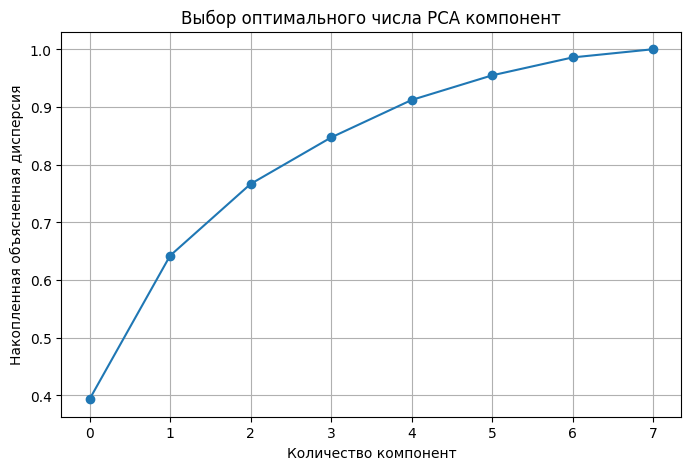

Количество компонент: 6


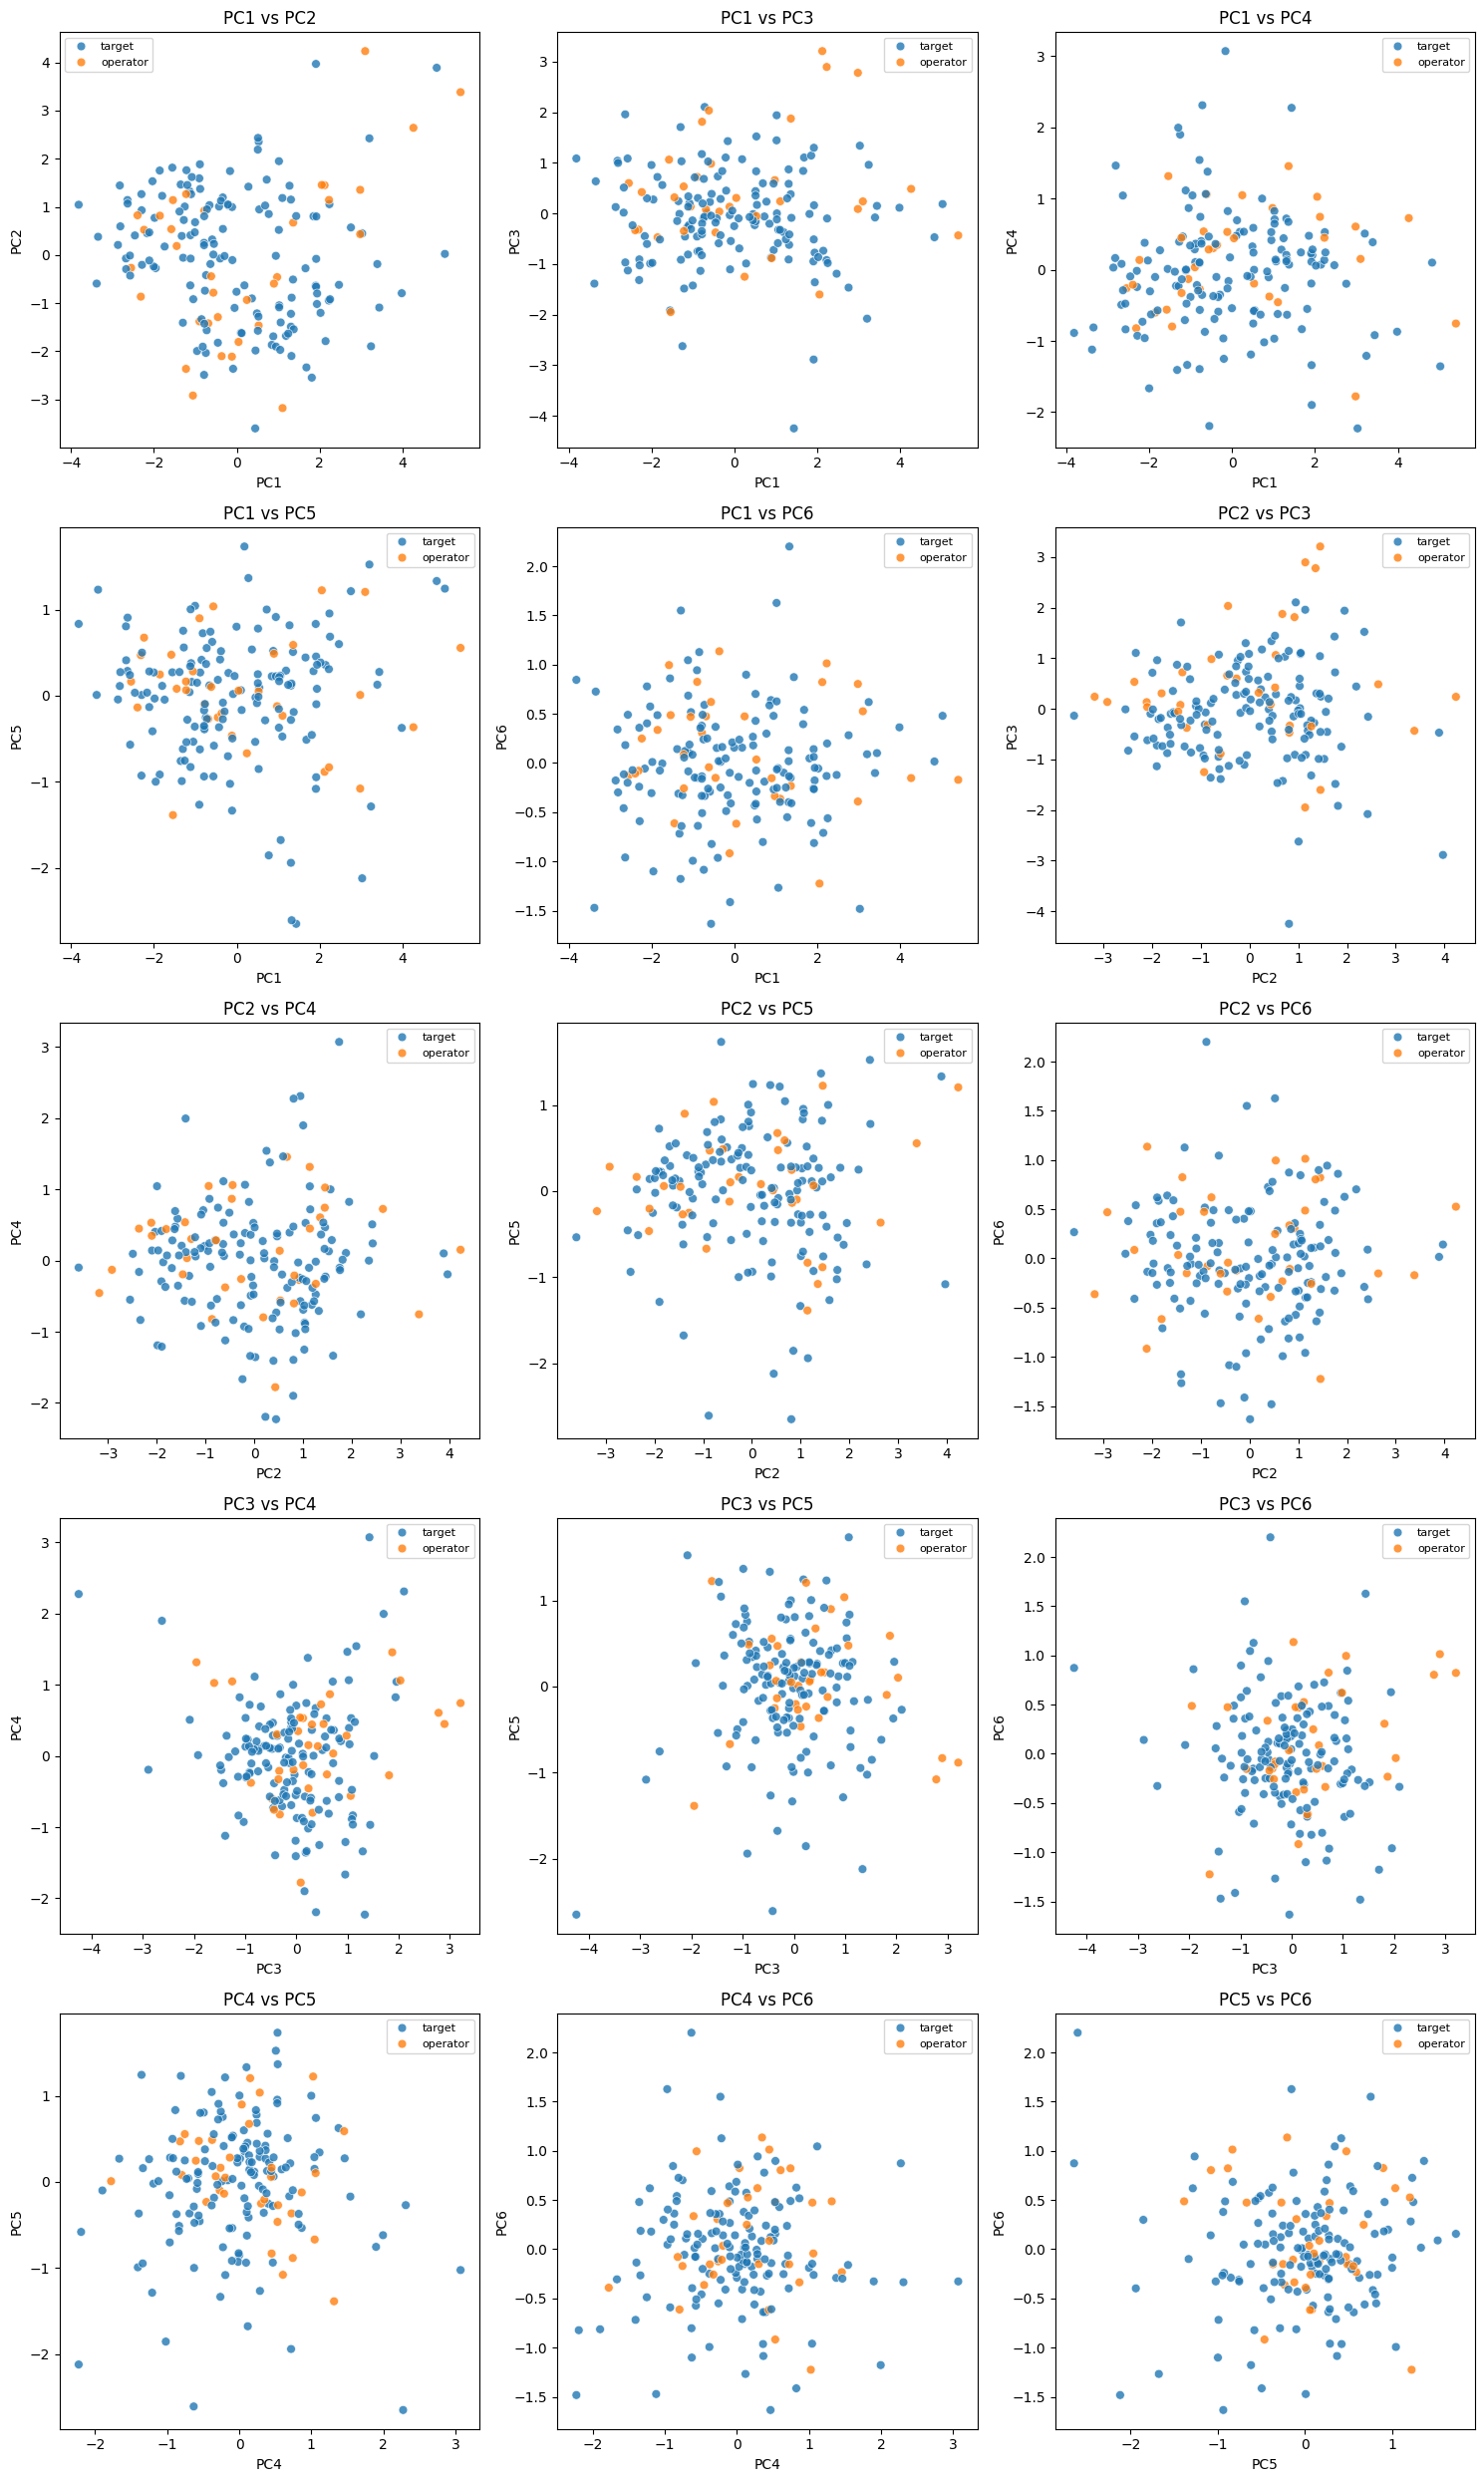

In [ ]:
hue_column="role"

pca_df, pairs = pca_equation(merged, hue_column=hue_column)
pca_plot(pca_df, pairs, hue_column=hue_column)

### Отношение мужчин/женщин в категории пользователь

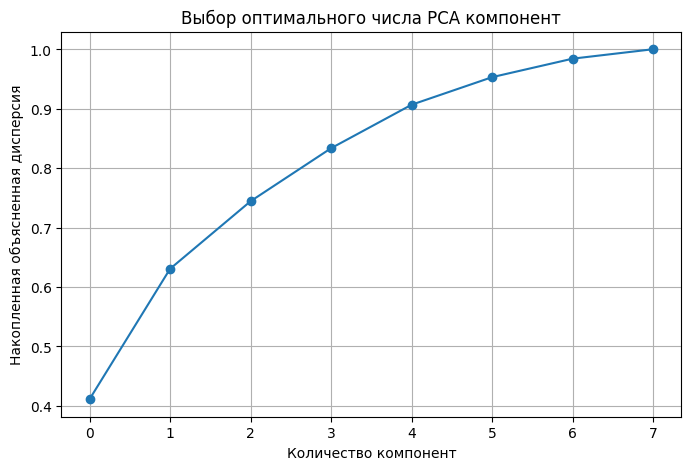

Количество компонент: 6


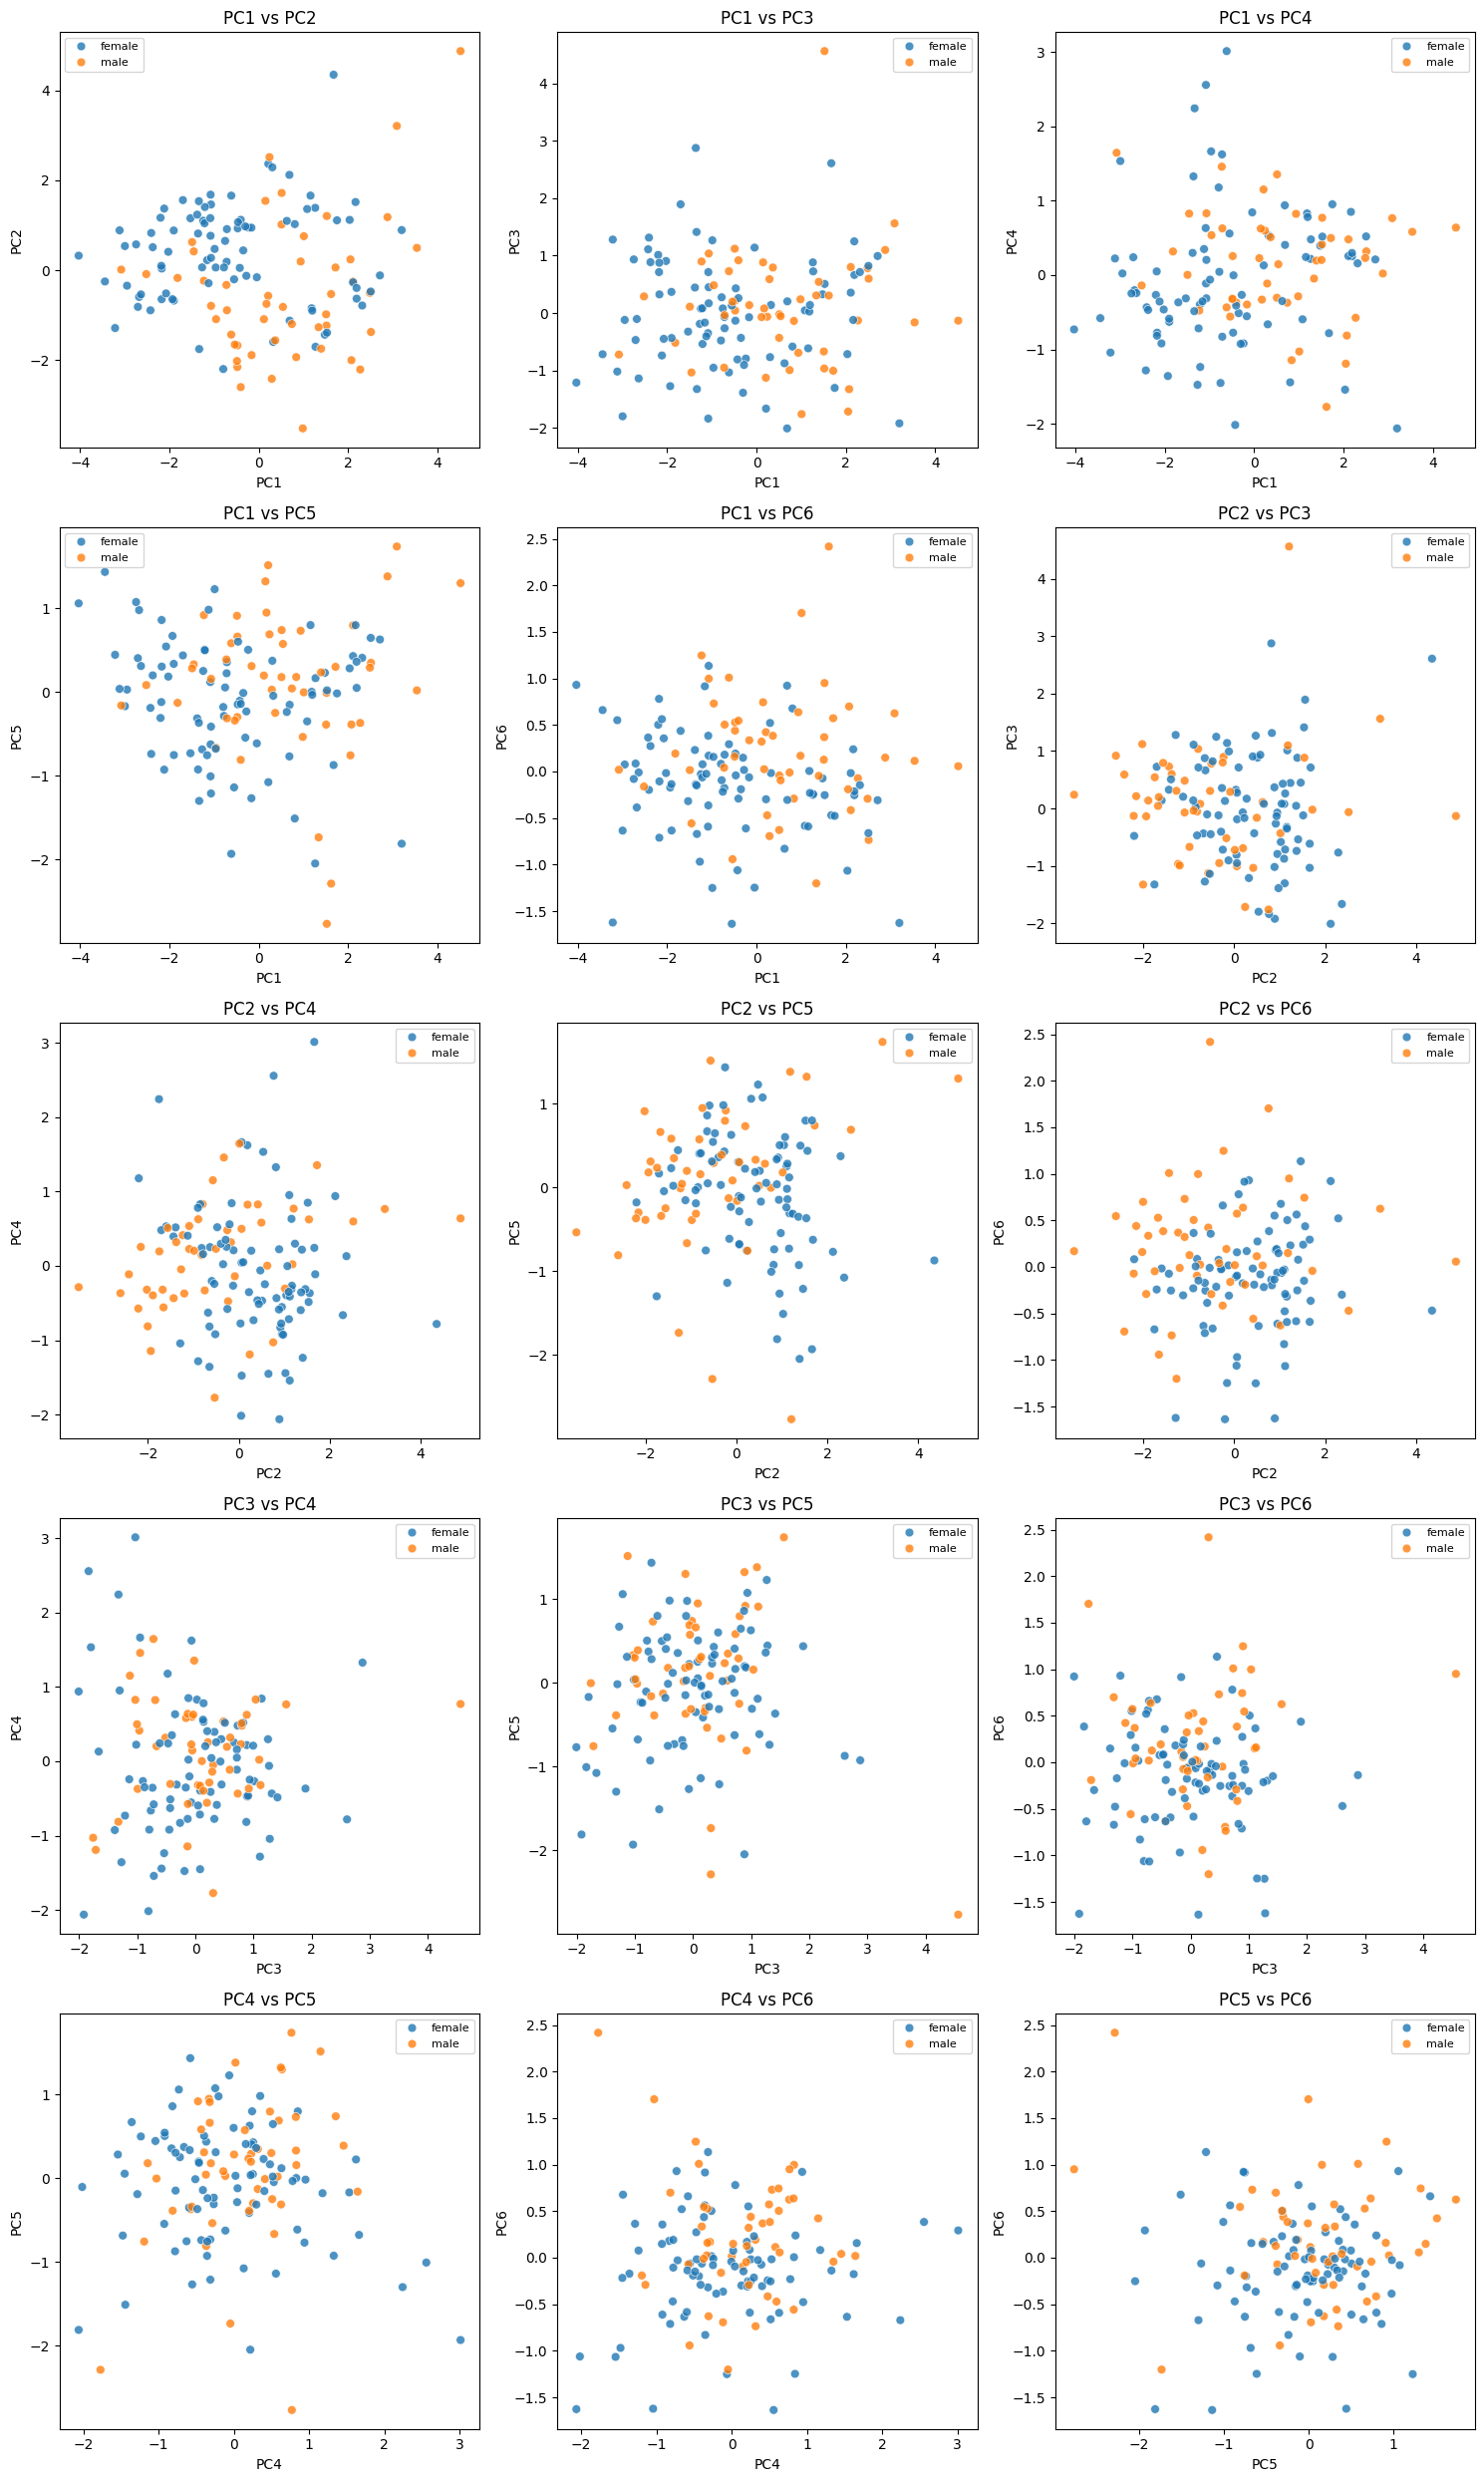

In [25]:
hue_column="sex"
df_target = merged[merged["role"]=="target"]

pca_df, pairs = pca_equation(df_target, hue_column=hue_column)
pca_plot(pca_df, pairs, hue_column=hue_column)

### Отношение мужчин/женщин в категории оператор

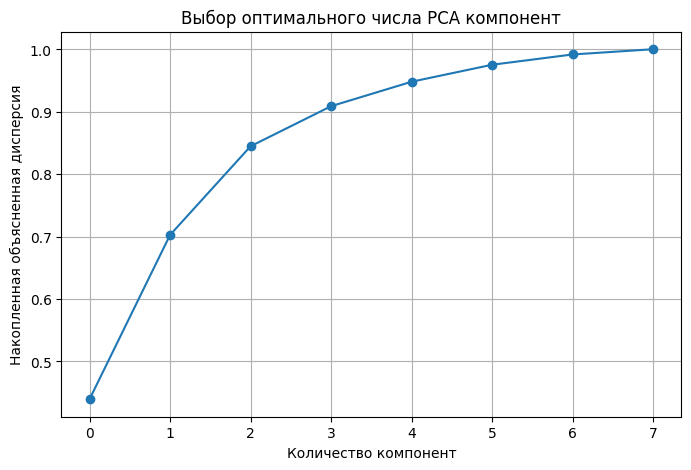

Количество компонент: 6


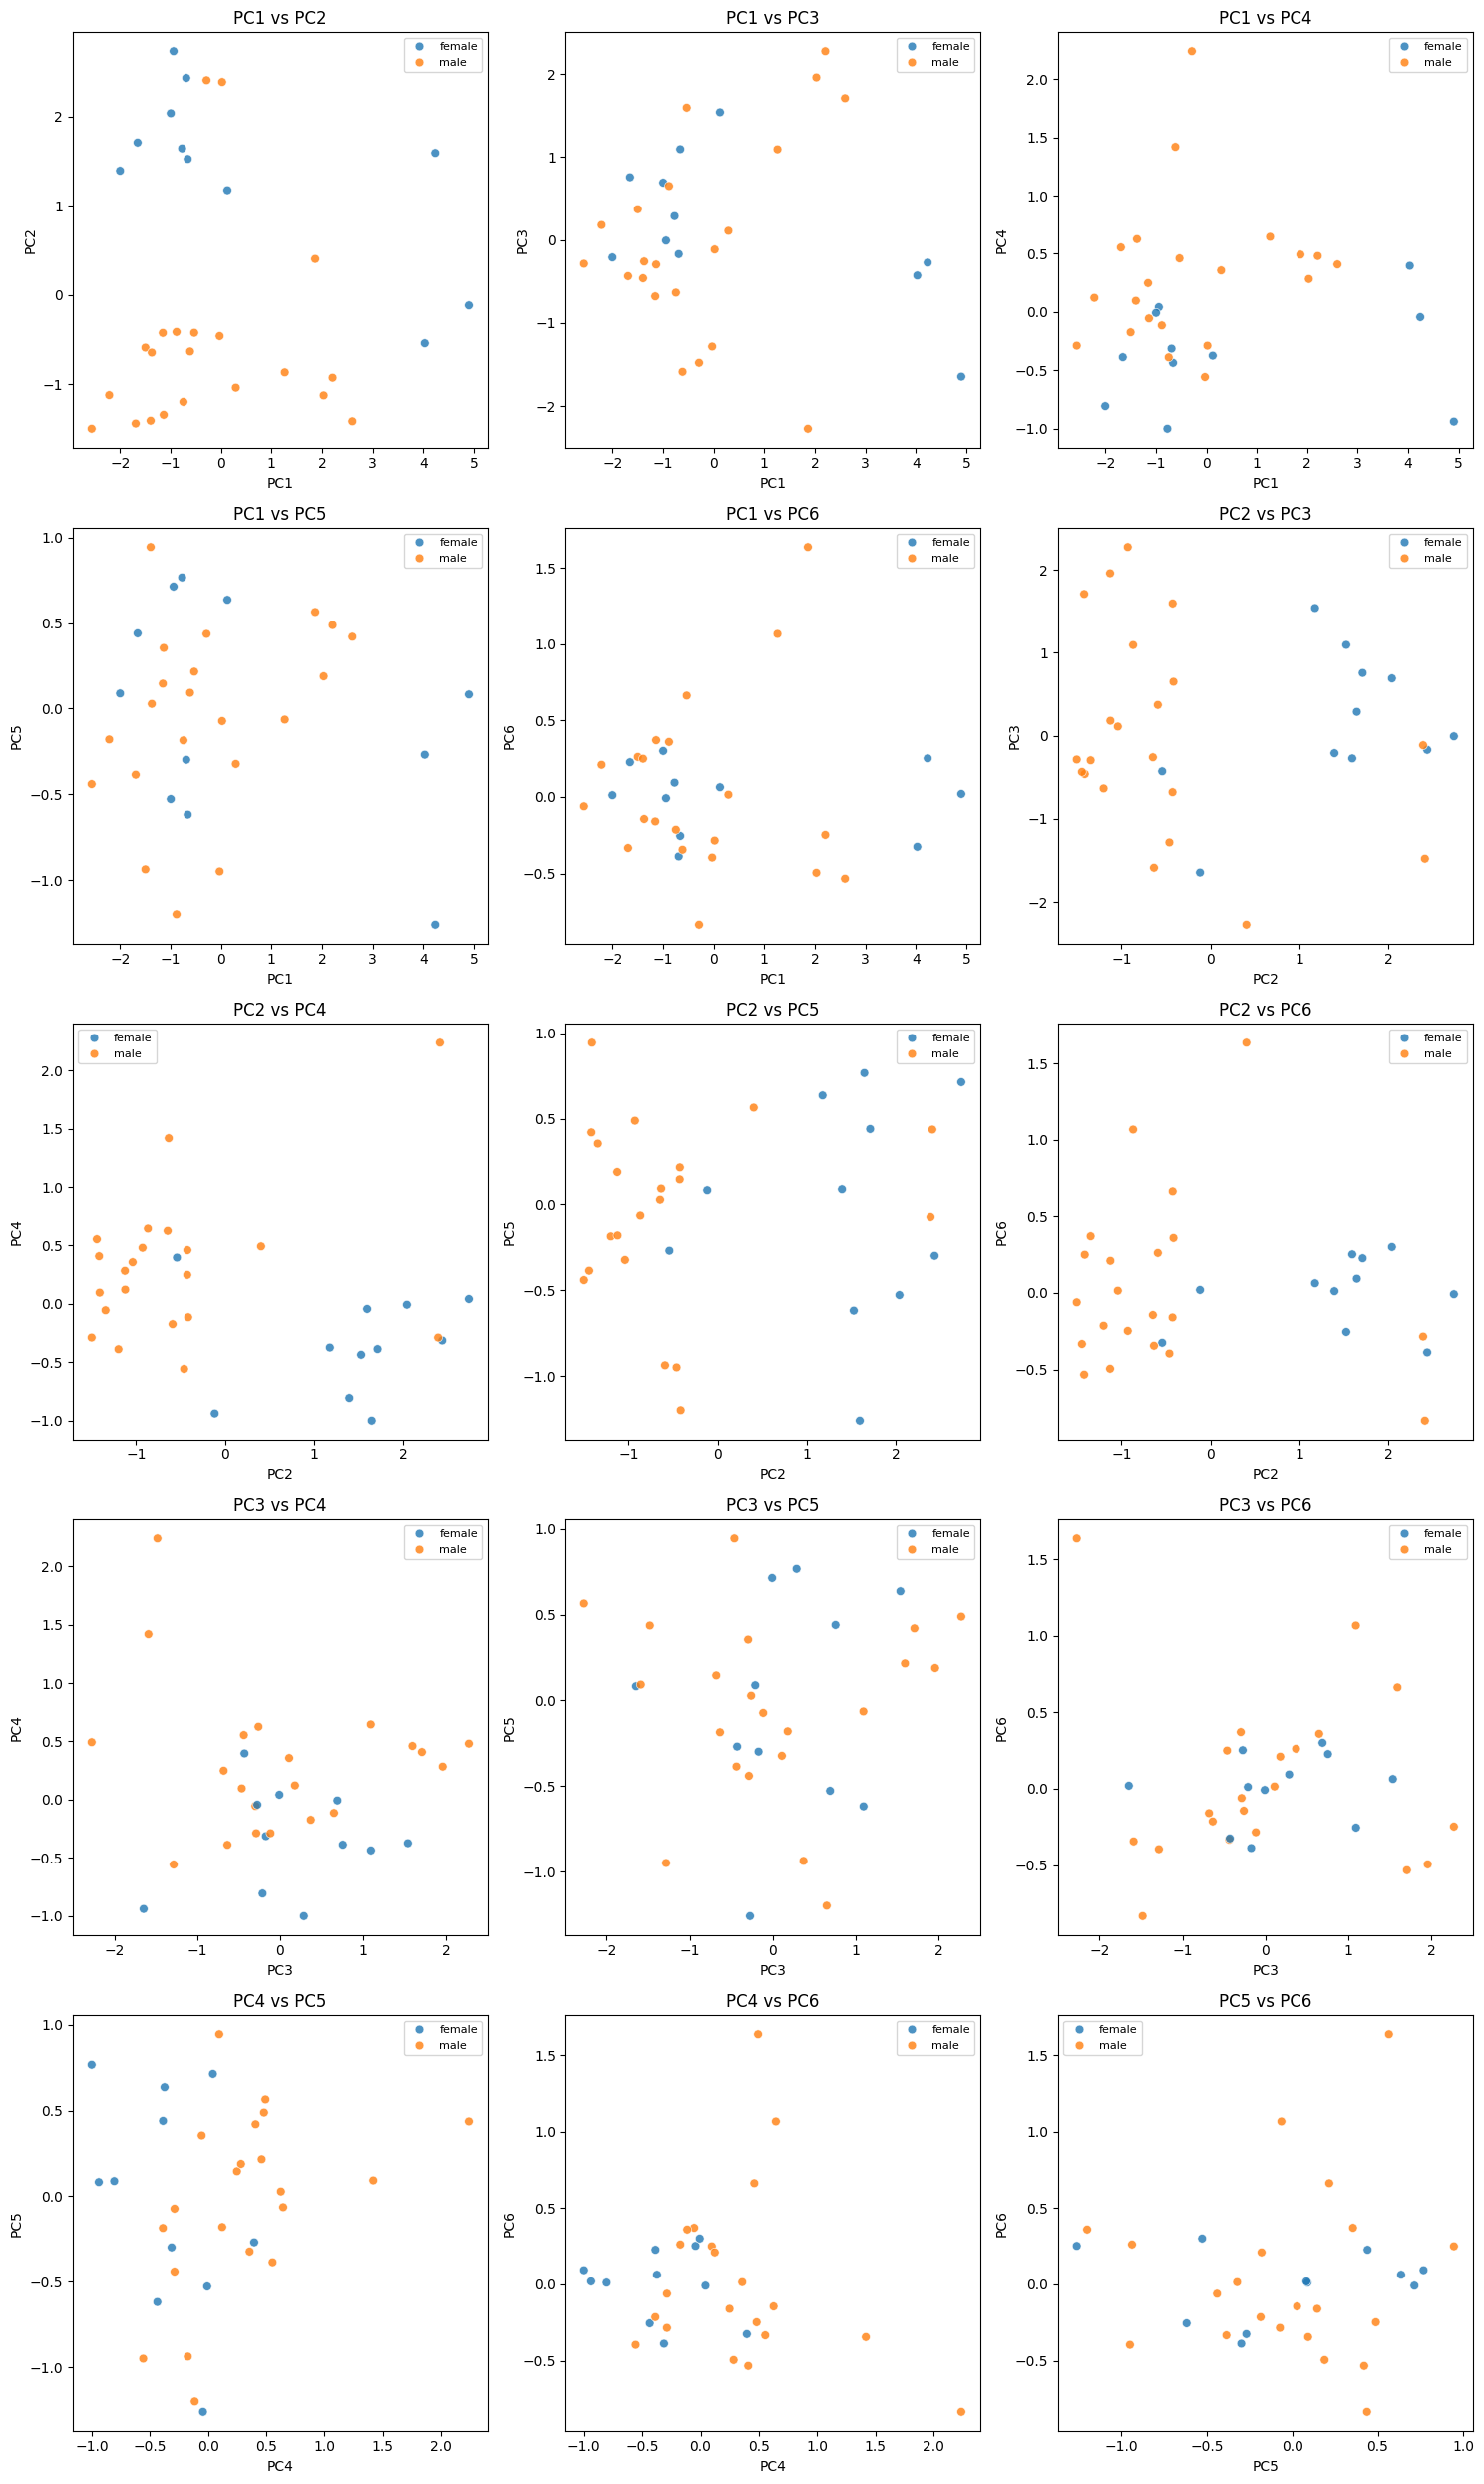

In [28]:
hue_column="sex"
df_operator = merged[merged["role"]=="operator"]

pca_df, pairs = pca_equation(df_operator, hue_column=hue_column)
pca_plot(pca_df, pairs, hue_column=hue_column)

### Отношение оператор/пользователь в категории мужчины

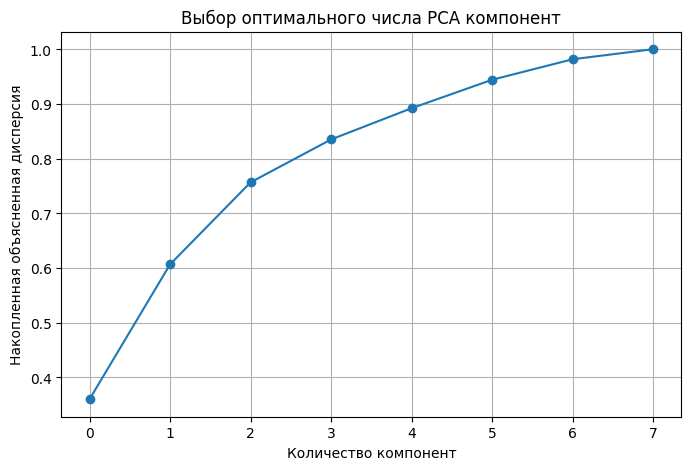

Количество компонент: 7


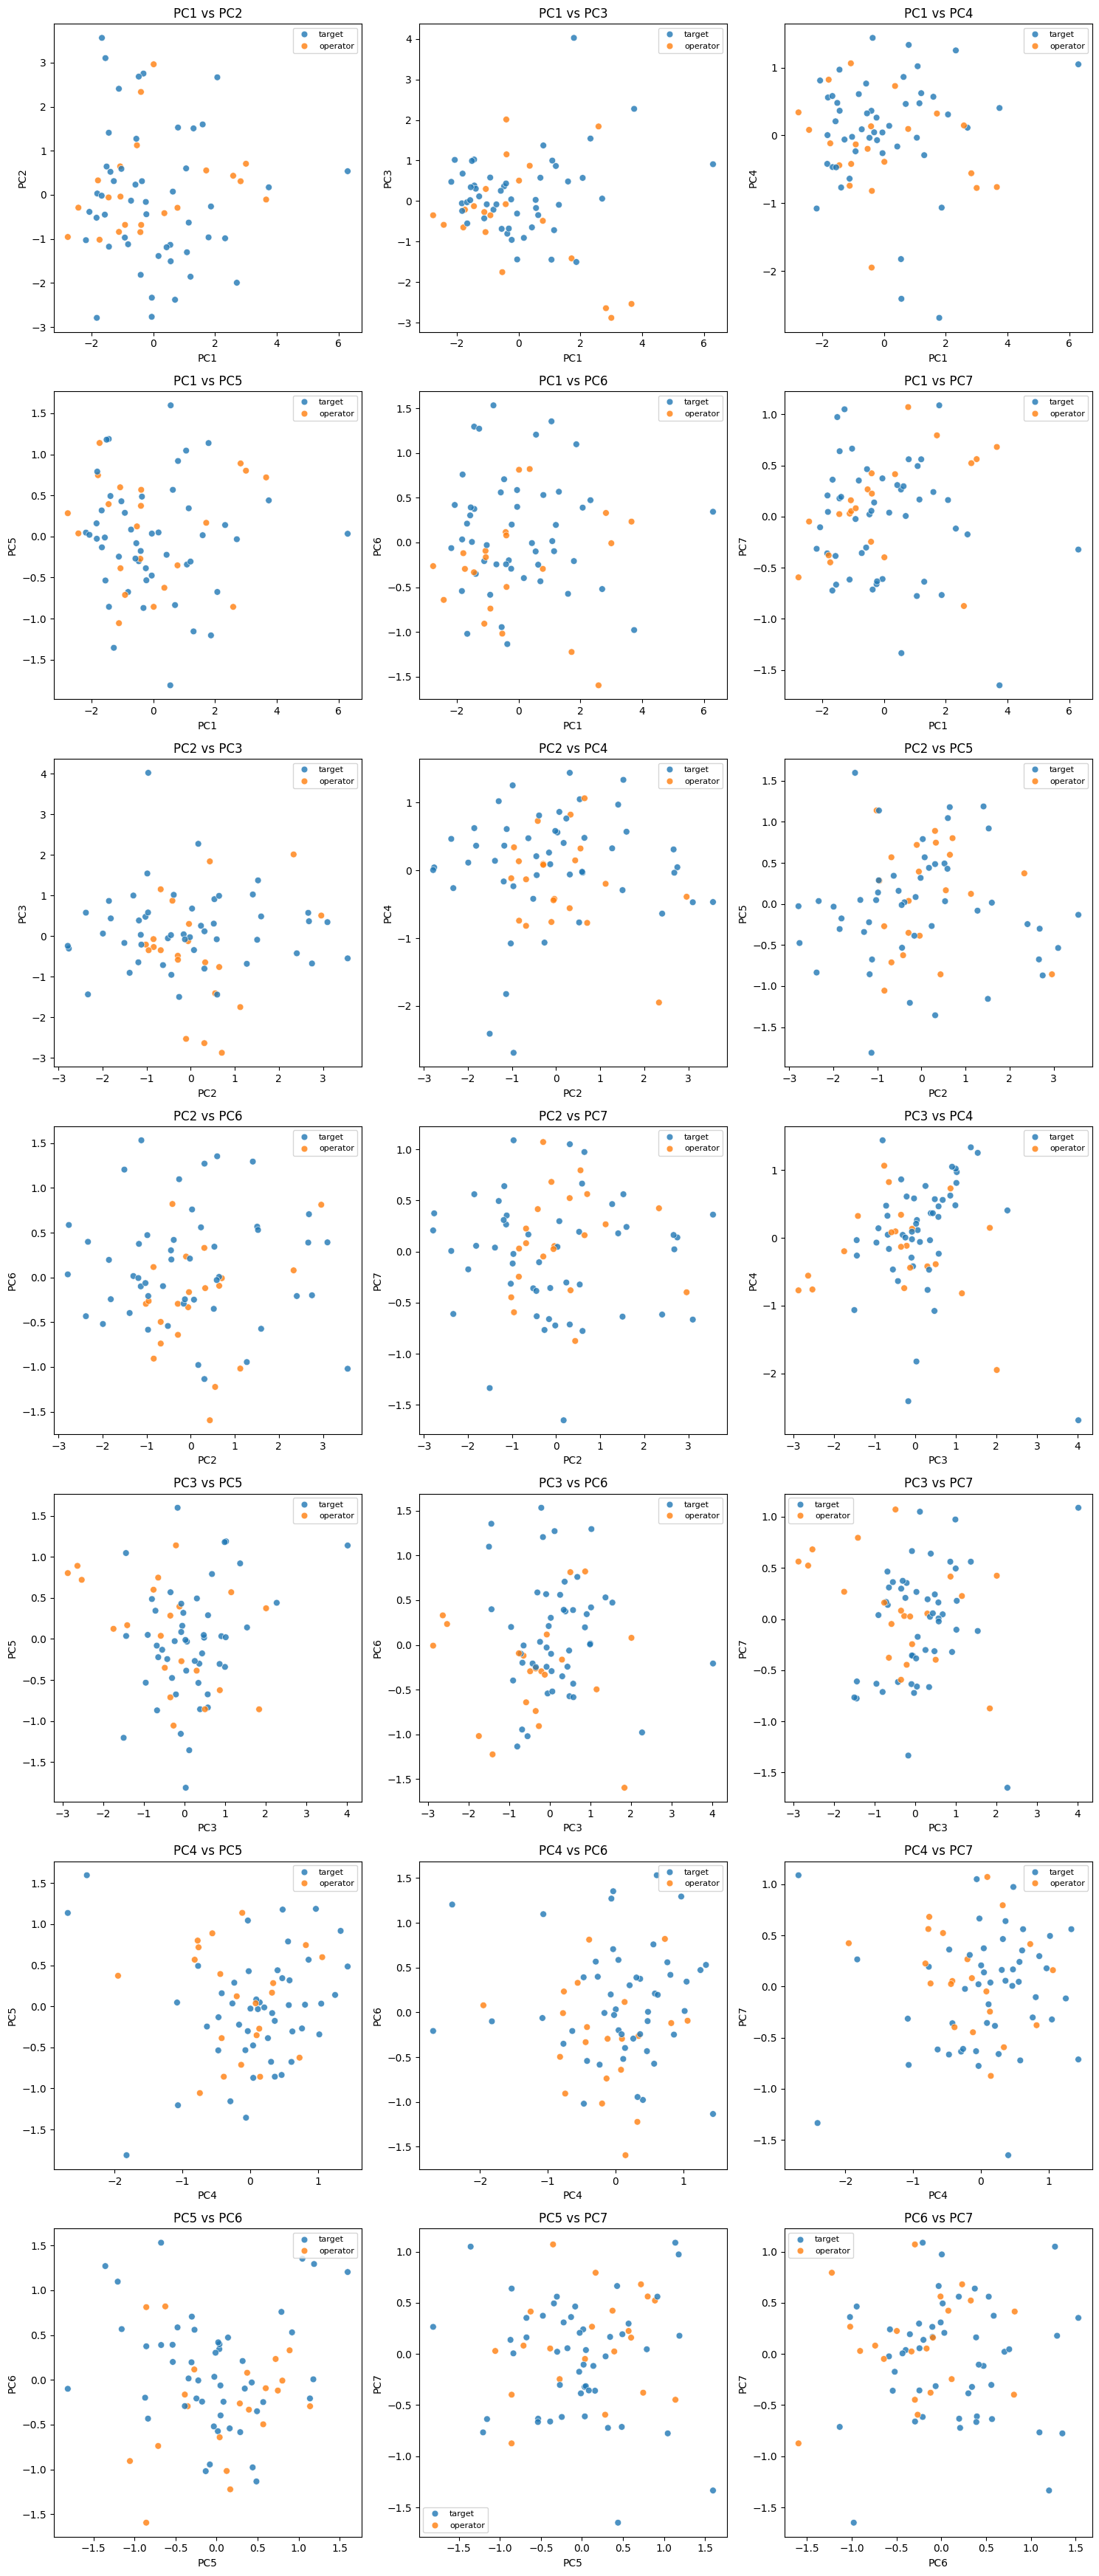

In [29]:
hue_column="role"
df_male = merged[merged["sex"]=="male"]

pca_df, pairs = pca_equation(df_male, hue_column=hue_column)
pca_plot(pca_df, pairs, hue_column=hue_column)

### Отношение оператор/пользователь в категории женщины

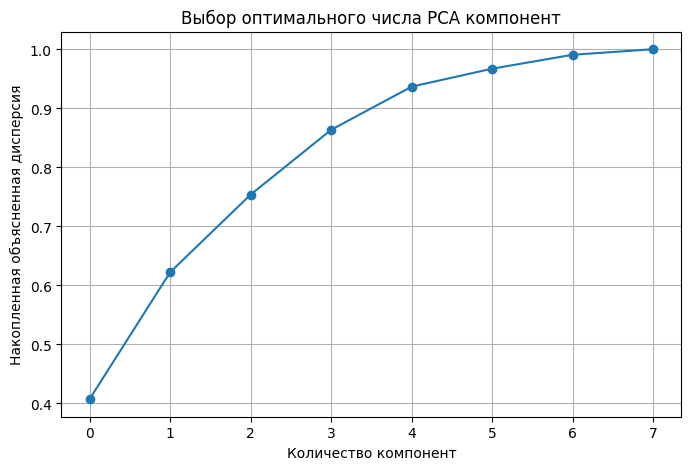

Количество компонент: 6


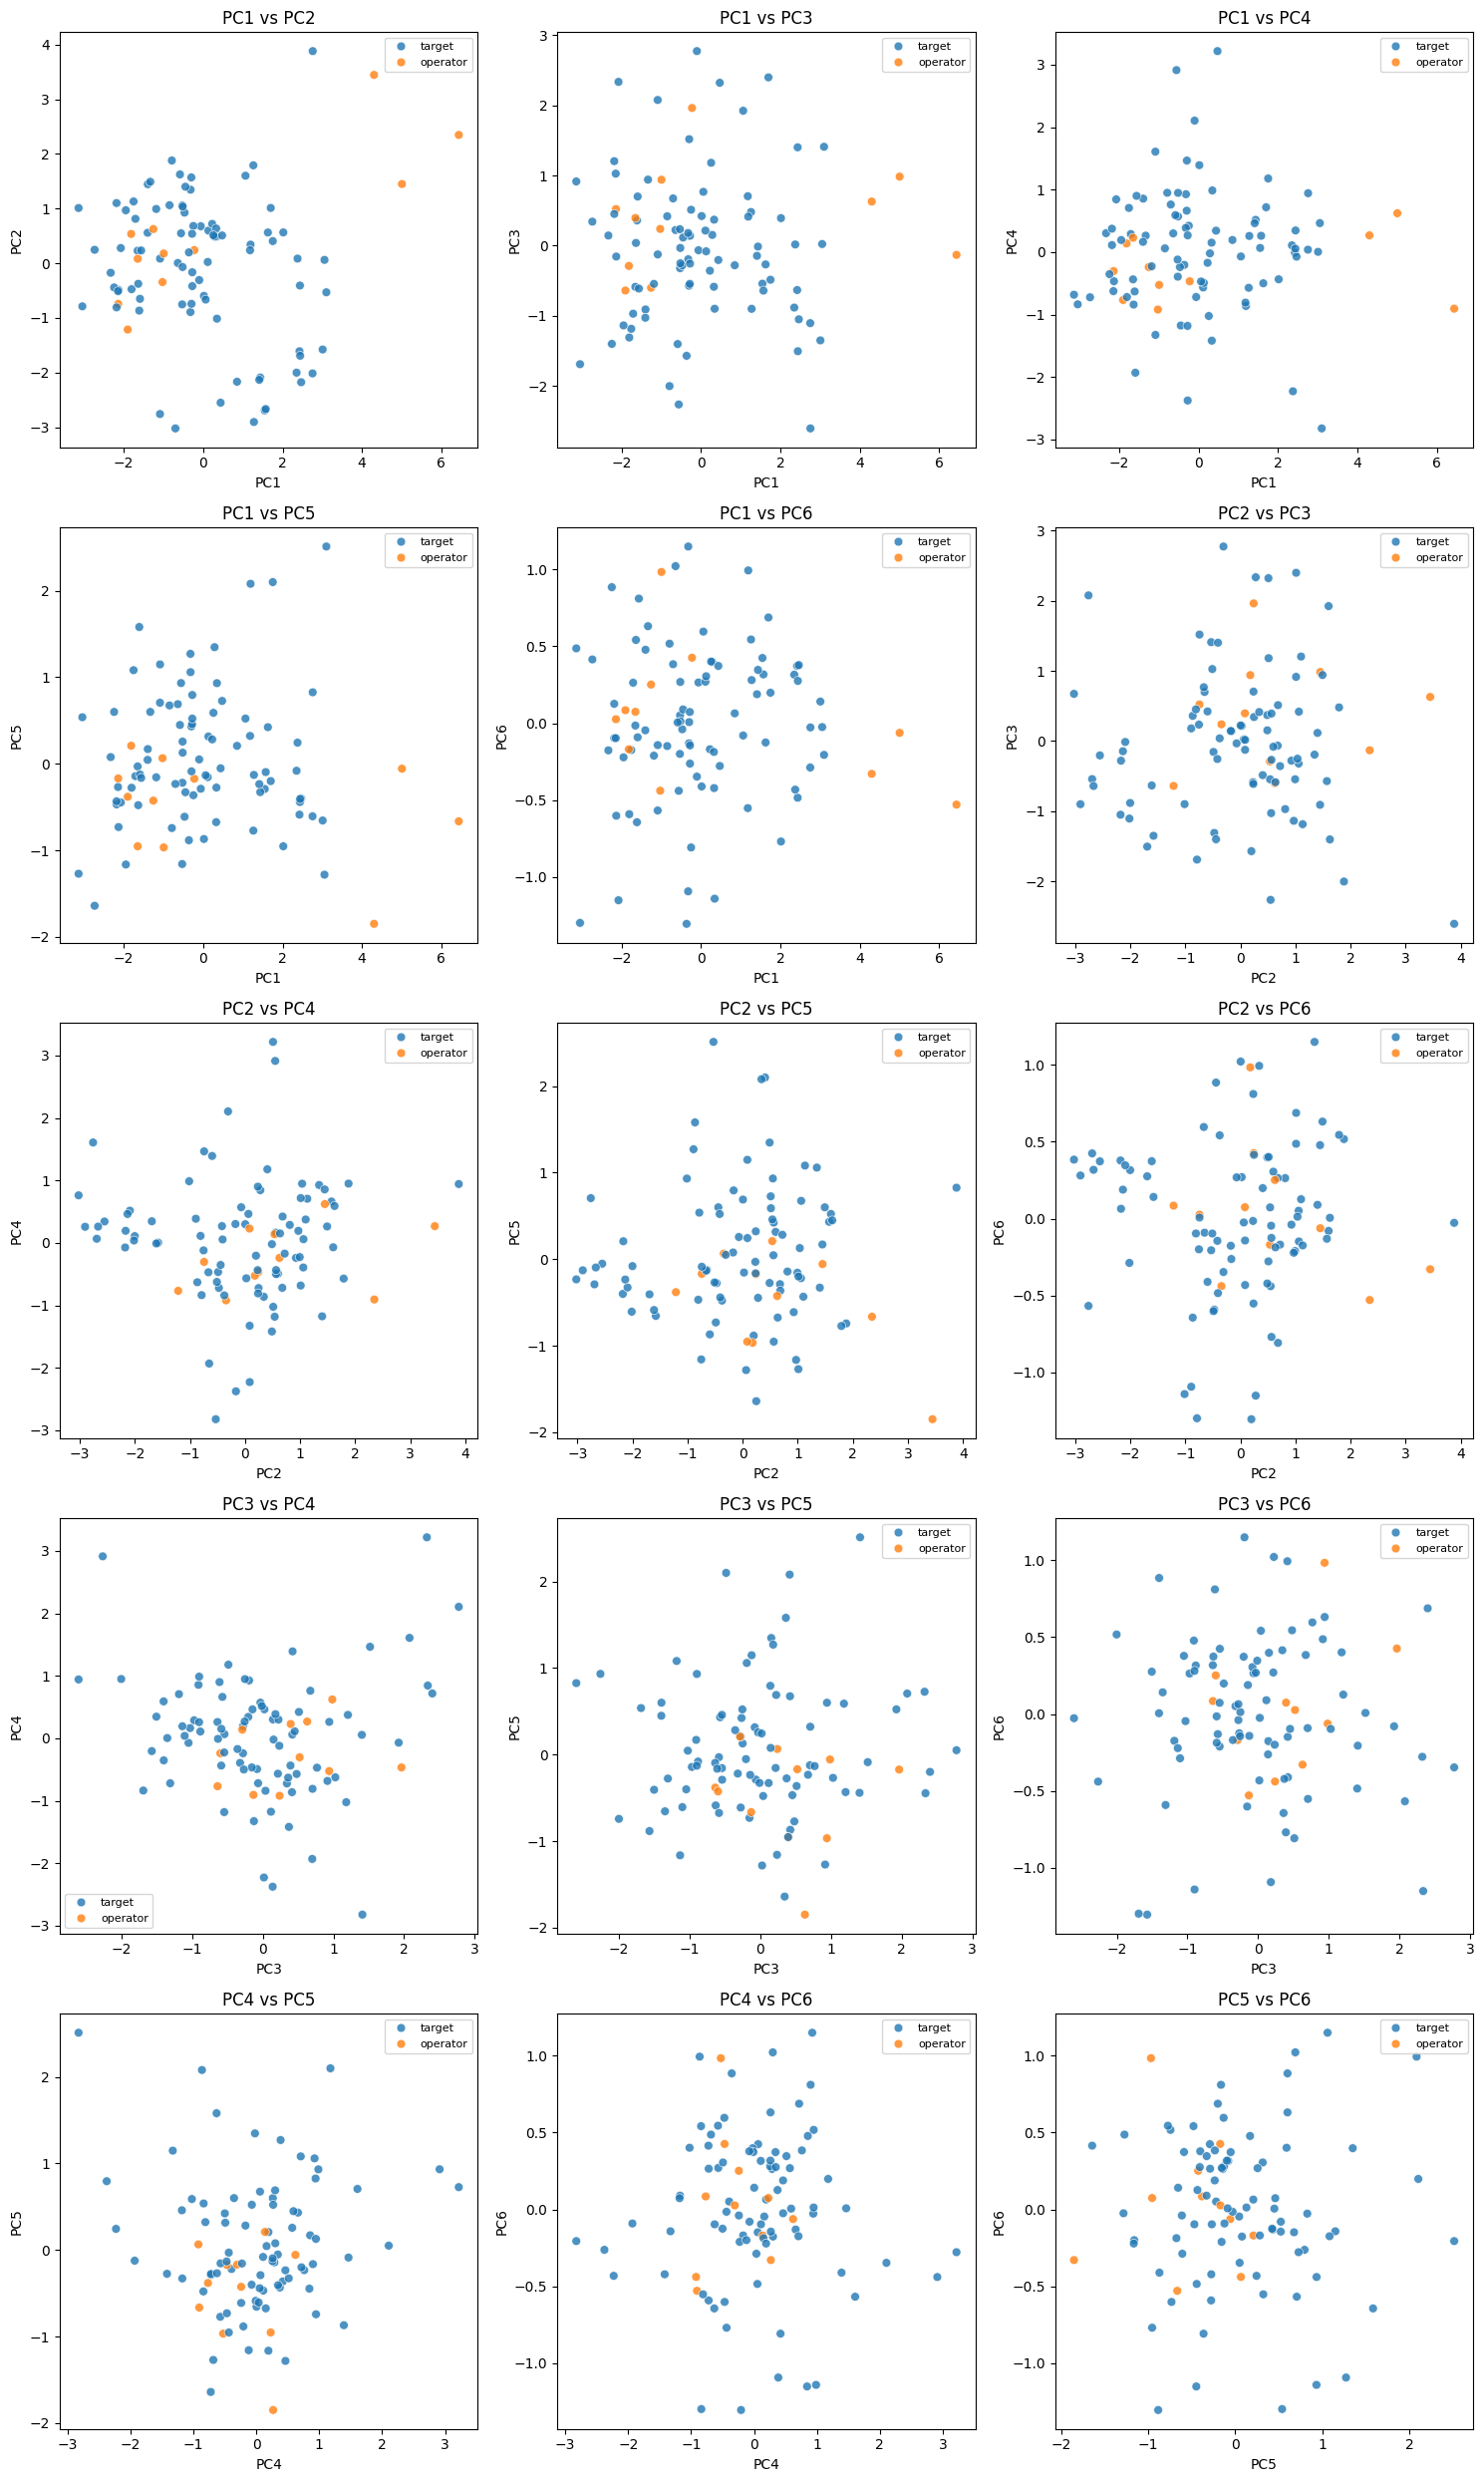

In [30]:
hue_column="role"
df_female = merged[merged["sex"]=="female"]

pca_df, pairs = pca_equation(df_female, hue_column=hue_column)
pca_plot(pca_df, pairs, hue_column=hue_column)